# 3. Dimensionality Reduction

To demonstrate dimensionality reduction and modal decomposition techniques, we simulate a synthetic **free-field acoustic wave propagation** problem in a 2D domain. 

The system models two distinct point sources emitting acoustic waves at different frequencies ($f_1 = 1307\text{ Hz}$ and $f_2 = 1700\text{ Hz}$) interacting over space and time:
* **Spatial Grid:** $N \times N$ mesh ($x, y \in [0, 1]\text{ m}$)
* **Temporal Grid:** $N$ time steps spanning multiple periods of the lower frequency.

In [28]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

Prepare data:

In [11]:
N = 200

c0 = 343                 #assume in m/s
f1 = 1307                #assume in Hz
f2 = 1700                #assume in Hz

w1 = 2*np.pi*f1
w2 = 2*np.pi*f2
k1 = w1/c0
k2 = w2/c0

# make 5 periods of the lower freq
t = np.linspace(0, 6/f1, N) #assume in seconds
x = np.linspace(0, 1, N) #assume in meters
y = np.linspace(0, 1, N) #assume in meters
X, Y = np.meshgrid(x, y, indexing='xy')

dx = x[1] - x[0]
dt = t[1] - t[0]

x1, y1 = -0.4, 0.33
x2, y2 = -0.4, 0.66
R1 = np.sqrt((x1 - X)**2 + (y1 - Y)**2)
R2 = np.sqrt((x2 - X)**2 + (y2 - Y)**2)

# Add dimensions for broadcasting:
R1 = R1[:, :, None]       # shape: (N, N, 1)
R2 = R2[:, :, None]       # shape: (N, N, 1)
T  = t[None, None, :]     # shape: (1, 1, N)

S1 = 1.4*np.cos(k1*R1 - w1*T) / np.sqrt(R1)
S2 = 1.1*np.cos(k2*R2 - w2*T) / np.sqrt(R2)

S = S1 + S2
DATA = S.reshape(N * N, N).T


### Proper Orthogonal Decomposition (POD / PCA)

POD / PCA decomposes the spatio-temporal dataset into orthogonal spatial modes ranked by their **energy content** (explained variance).

* **Spatial Modes ($V$):** Represent the dominant structural shapes vibrating in the domain.
* **Temporal Coefficients ($U \Sigma$):** Describe how those spatial shapes evolve and scale over time.

In [12]:
pca = PCA(n_components=6)
coefficients = pca.fit_transform(DATA)

# Spatial POD modes
modes = pca.components_.reshape(
    pca.n_components_,
    N,
    N
)

print(modes.shape)
# (n_modes, Ny, Nx)

print(coefficients.shape)
# (Nt, n_modes)

energy = pca.explained_variance_ratio_
print("Explained variance / POD energy:")
print(energy)


(6, 200, 200)
(200, 6)
Explained variance / POD energy:
[3.14776063e-01 3.10760610e-01 1.92119901e-01 1.82343426e-01
 2.03119229e-32 1.13175351e-32]


Plot first 3 POD modes and the 3 temporal POD coefficients


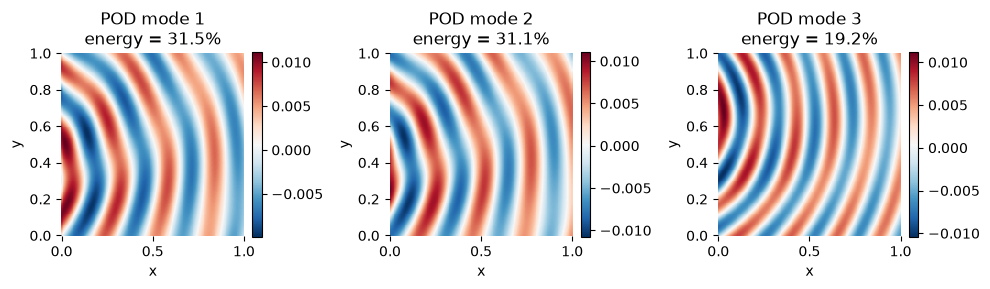

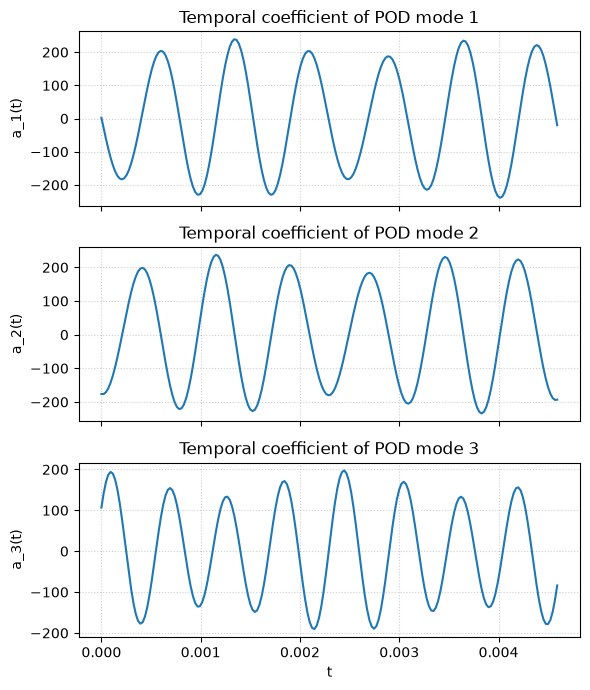

In [13]:
plt.figure(figsize=(10, 5))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    
    im = plt.pcolor(x, y, modes[i], shading='auto', cmap='RdBu_r')
    
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        f"POD mode {i+1}\n"
        f"energy = {100*energy[i]:.1f}%"
    )
    plt.gca().set_aspect('equal', adjustable='box')
    # Hide the bounding box (spines)
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 7))
for i in range(3):
    plt.subplot(3, 1, i + 1)
    
    plt.plot(t, coefficients[:, i])
    plt.ylabel(f"a_{i+1}(t)")
    plt.title(f"Temporal coefficient of POD mode {i+1}")
    plt.grid(True, linestyle=":", alpha=0.6)
    
    # Only show x-label on the bottom subplot
    if i == 2:
        plt.xlabel("t")
    else:
        plt.tick_params(labelbottom=False)

plt.tight_layout()
plt.show()

### Dynamic Mode Decomposition (DMD)

In [14]:
# --- DMD Implementation (Brunton & Kutz) ---
def DMD(X, Xprime, r):
    # Step 1: Truncated SVD
    U, Sigma, VT = np.linalg.svd(X, full_matrices=0)
    Ur = U[:, :r]
    Sigmar = np.diag(Sigma[:r])
    VTr = VT[:r, :]
    
    # Step 2: Low-rank linear operator
    Atilde = np.linalg.solve(Sigmar.T, (Ur.T @ Xprime @ VTr.T).T).T
    
    # Step 3: Spectral decomposition of Atilde
    Lambda, W = np.linalg.eig(Atilde)
    Lambda = np.diag(Lambda)
    
    # Step 4: Exact DMD modes and mode amplitudes
    Phi = Xprime @ np.linalg.solve(Sigmar.T, VTr).T @ W
    alpha1 = Sigmar @ VTr[:, 0]
    b = np.linalg.solve(W @ Lambda, alpha1)
    
    return Phi, Lambda, b

In [25]:
DATA = S.reshape(N * N, N)

DATAp = DATA[:, 1:]
DATA = DATA[:, :-1]

r = 4  # DMD rank

# Call the DMD function
Phi, Lambdas, b = DMD(DATA, DATAp, r)

eigvals = np.diag(Lambdas)
# Compute omegas and frequencies
omegas = np.log(eigvals) / dt
freqs = np.imag(omegas / (2 * np.pi)).ravel()

In [26]:
# --- Print Conjugate Pairs & Frequencies Analysis ---
print("--- DMD Mode Analysis: Conjugate Pairs & Frequencies ---")
visited = set()

for i in range(len(eigvals)):
    if i in visited:
        continue
    
    val_i = eigvals[i]
    
    # Static or pure decay mode (Real)
    if np.isclose(np.imag(val_i), 0.0, atol=1e-6):
        visited.add(i)
        print(f"Mode {i+1}: Real (Static/Decay)   | Freq: {freqs[i]:6.2f} Hz | λ: {val_i:.4f}")
    else:
        # Complex conjugate pair
        found_pair = False
        for j in range(i + 1, len(eigvals)):
            if j not in visited and np.isclose(val_i, np.conj(eigvals[j]), atol=1e-5):
                visited.add(i)
                visited.add(j)
                print(f"Modes {i+1} & {j+1}: Conjugate Pair  | Freq: ±{abs(freqs[i]):5.2f} Hz | λ: {val_i:.4f}")
                found_pair = True
                break
        
        if not found_pair:
            visited.add(i)
            print(f"Mode {i+1}: Unpaired Complex    | Freq: {freqs[i]:6.2f} Hz | λ: {val_i:.4f}")

--- DMD Mode Analysis: Conjugate Pairs & Frequencies ---
Modes 1 & 2: Conjugate Pair  | Freq: ±1307.00 Hz | λ: 0.9821+0.1883j
Modes 3 & 4: Conjugate Pair  | Freq: ±1700.00 Hz | λ: 0.9698+0.2439j


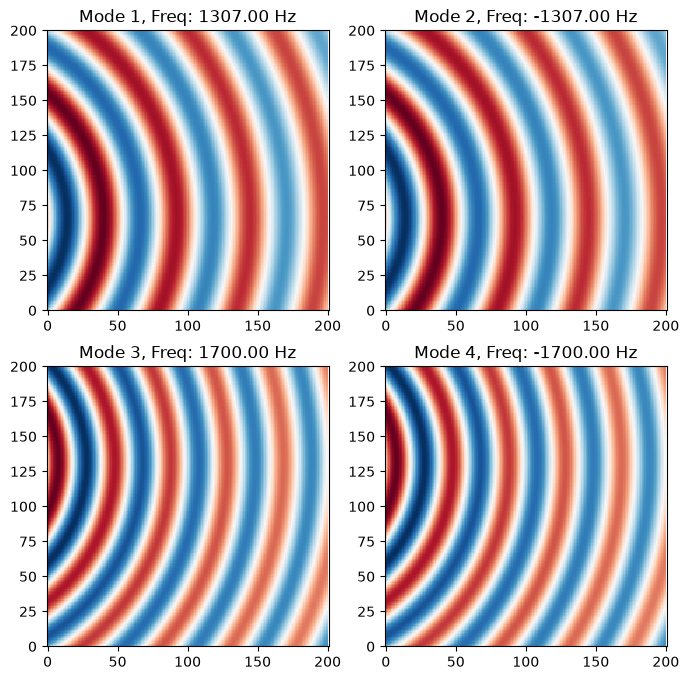

In [27]:
# Reshape the modes for plotting
Phi1 = np.reshape(Phi[:, 0], (N, N))
Phi2 = np.reshape(Phi[:, 1], (N, N))
Phi3 = np.reshape(Phi[:, 2], (N, N))
Phi4 = np.reshape(Phi[:, 3], (N, N))

plt.figure(figsize=(8, 8))
plt.subplot(221)
plt.pcolor(np.real(Phi1), shading='auto', cmap='RdBu_r')
plt.title(f"Mode 1, Freq: {freqs[0]:.2f} Hz")
plt.axis('equal')

plt.subplot(222)
plt.pcolor(np.real(Phi2), shading='auto', cmap='RdBu_r')
plt.title(f"Mode 2, Freq: {freqs[1]:.2f} Hz")
plt.axis('equal')

plt.subplot(223)
plt.pcolor(np.real(Phi3), shading='auto', cmap='RdBu_r')
plt.title(f"Mode 3, Freq: {freqs[2]:.2f} Hz")
plt.axis('equal')

plt.subplot(224)
plt.pcolor(np.real(Phi4), shading='auto', cmap='RdBu_r')
plt.title(f"Mode 4, Freq: {freqs[3]:.2f} Hz")
plt.axis('equal')
plt.show()